# ES1 – MACHINE LEARNING
## Entrenamiento de una red neuronal para clasificación de imágenes

**Integrantes:**  
-  Víctor Rubilar
-  Alexis Salazar
-  Maximiliano Gonzalez

**Sección:** Machine-N8-Elec IEI-C1/D

**Asignatura:** Machine Learning  

**Docente:**  Manuel Alfredo Sanchez Carcamo

**Fecha:** 11-09-2026



# 1. Descripción del problema


**Respuesta de la dupla:**
Una empresa dedicada a la comercialización de prendas necesita realizar la automatización del proceso de clasificación de su ropa para ello se necesita entranr una red neuronal la cual debe identificar y reconocer las imagenes indicando claramente el objeto que se encuentra dentro de la imagen, el objetvo de la solución es proporcionar un modelo que sea capaz de identificar las imagenes mencionando el nombre de lo que se encuentra en la imagen.



In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ["KERAS_BACKEND"] = "torch"  # Ejecuta sobre PyTorch por debajo
import keras
from keras import layers
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


# 2. Tipo de aprendizaje automático


**Tipo de aprendizaje:**  Aprendizaje Supervisado

**Justificación:** Al tener el dataset el campo de etiqueta indicando el objeto correcto de cada imagen, usamos el entrenamiento supervisado para decirle al momento de entrenar cual es la respuesta correcta.


In [17]:
# Esta sección es principalmente de análisis. No requiere código obligatorio.


# 3. Identificación de los datos
[Descripción]

- **X:**  Pixeles de la imagen en escala de grises con valores entre 0 y 255 (28x28)
- **y:**  Etiqueta de objeto correcto
- **Cada observación representa:**  
- **Las etiquetas representan:**  El objeto correcto de cada imagen
- **Dimensiones iniciales de X:**  (28x28)
- **Dimensiones iniciales de y:**(e) = etiqueta


In [18]:
# Carguen el dataset e inspeccionen su estructura.
# Pueden utilizar como base el archivo de carga entregado por el docente.


datos = np.load("fashion_mnist_es1_6000.npz")

X = datos["X"]
y = datos["y"]
clases = datos["clases"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Clases:", clases)


Forma de X: (6000, 28, 28)
Forma de y: (6000,)
Clases: ['T-shirt/top' 'Trouser' 'Pullover' 'Dress' 'Coat' 'Sandal' 'Shirt'
 'Sneaker' 'Bag' 'Ankle boot']


# 4. Preparación de los datos

[Descripción]



| Transformación realizada | ¿Por qué se realizó? | Resultado obtenido |
|---|---|---|
| Cambio en dimensiones | las redes neuronales convulcionales necesita de el campo segun la escala de colores  | antes: (n, 28, 28) ahora: (-1, 28, 28, 1) |
| Normalización de pixeles | para tener alores entre 0 y 1 | se obtiene un valor entre 0 y 1 ejemplo: 200 / 255: 0,784 |


In [19]:
# 1. Preprocesamiento de los datos
# -1 indica la cantidad de datos la cual se ajusta automaticamente
# 28, 28 tamaño de la imagen
# 1 indica que es una imagen en escala de grises, como dato para una rgb se usaria 3
# por utlimo normalizamos los datos para que tenga un valor entre 0 y 1 diviendo entre 255
# esto es porque los pixeles de escalade grises contienen valores entre el 0 y 255 
X =  X.reshape(-1, 28, 28, 1) / 255.0


# 5. Separación de los datos

[Descripción]

**Porcentaje destinado a entrenamiento:**  80%

**Porcentaje destinado a prueba:**  20%

**Justificación de la proporción utilizada:** Al ser un conjunto de 6000 registros no se necesitas mas que eso, con el 80% (4800) el modelo puede obtener suficiente información sin tener overfitting


In [20]:
# 2. Separamos el entrenamiento en 80% (4800) de datos de entrenar y 20% (1200) en datos de test
# la variable y que es la etiqueta es la que queremos predecir
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 6. Diseño de la red neuronal

6.0 Configurar el modelo
6.1 primero se definen 2 capas donde la primera tiene 32 nucleos los cuales se encarga de encontrar caracteristicas en un tamaño de 3x3 \n
a esto le definimos la forma de los datos que es (28, 28, 1)


6.2 luego se reduce a un vector bidimensional con el fin de reducir el costo de computo

6.3 segunda neurona convulcional de 64 nucleos, aca busca areas mas grandes que la primera teniendo un mayor nivel de abastracción


6.4 la 3 capa son 64 neuronas encuentra las relaciones entre los patrones formando figuras completas usando relu para relaciones no lineales complejas

6.4 luego se reduce a un vector bidimensional con el fin de reducir el costo de computo

6.5 capa final que decide la clase final cada neurona con una clase
con softmax cada clase se le da un % de cual es mas probable de ser la clase correcta

6.6  despues de cada capa de neuronas se incluye un dropout, que es una tecnica
que desactiva algunas neuronas dandole valor 0 generando que las neuronas restantes tengan que aprender a generalizar mejor y no depender de otras neuronas
esto ayuda a evitar el sobreajuste

- **Cantidad de capas ocultas:**  3
- **Neuronas por capa:**  (1,32) (2, 64) (3, 64)
- **Función de activación:**  Relu para las capas ocultas y softmax para la capa de salida
- **Motivo de esta configuración:** 
Con dropout evitamos que las neuronas se vuelvan peresosas (lazy neurons)mientras que con las capas convulcionales se buscan caracteristicas dentro de las imagenes como lineas rectas, o formas, para finalizar la ultima capa une los patrones detectados y llegamos a la capa de salida


In [21]:
# Escriban aquí el código utilizado para crear el modelo.

keras.utils.set_random_seed(42)


model = keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        # Bloque convolucional 1
        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),  
        # Bloque convolucional 2
        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),
        # Clasificador
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),  
        layers.Dense(10, activation="softmax"),
    ]
)


# compilamos el modelo antes del entrenamiento
# usando adam como funcion de gradiente, sparse_categorical_crossentropy como funcion de perdida
# y metrica de rendimiento accruracy
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)


# 7. Entrenamiento del modelo
[Descripción]
- **Cantidad de epocas:** 20
- **Pasos por entrenamiento:** 4800 / 32 = 150



In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
)




Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4617 - loss: 1.4775 - val_accuracy: 0.7467 - val_loss: 0.7737
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6669 - loss: 0.9207 - val_accuracy: 0.7667 - val_loss: 0.6353
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7156 - loss: 0.8013 - val_accuracy: 0.7767 - val_loss: 0.5911
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7348 - loss: 0.7038 - val_accuracy: 0.8000 - val_loss: 0.5343
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7510 - loss: 0.6625 - val_accuracy: 0.8000 - val_loss: 0.5187
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7690 - loss: 0.6337 - val_accuracy: 0.8008 - val_loss: 0.5227
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7633 - loss: 0.6177 - val_accuracy: 0.8175 - val_loss: 0.4979
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7825 - loss: 0.5732 - val_accu

# 8. Evaluación del modelo

En esta sección se presentan las metricas donde se evalua el modelose puede visualizar las siguientes metricas: 

- **Exactitud obtenida:**  83.89%
- **recall**: 83.67%
- **f1-score**: 83.40%


La imagen con mayor precision fue Anpkle boot con 99.12% mientras que la menor precicion fue la clase shirt con 58,88%, teniendo bastante diferencia entre si. esta metrica mide el porcentaje de precision de las clases positivas

La imagen con mayor recall fue bag con 96.67% mientras que la menor precicion fue  nuevamente la clase bag con 52,50%, teniendo bastante diferencia entre si.


In [23]:

# Predicción y reporte
predictions = model.predict(X_test)
y_pred = predictions.argmax(axis=1)
nombres_clases = [str(c) for c in clases]


# Reporte y metricas de rendimiento

reporte = classification_report(
    y_test,
    y_pred,
    target_names=nombres_clases,
    digits=4,  
)

print(reporte)


 1/38 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

 T-shirt/top     0.7786    0.8500    0.8127       120
     Trouser     0.9826    0.9417    0.9617       120
    Pullover     0.8333    0.6250    0.7143       120
       Dress     0.8358    0.9333    0.8819       120
        Coat     0.7218    0.8000    0.7589       120
      Sandal     0.9487    0.9250    0.9367       120
       Shirt     0.6121    0.5917    0.6017       120
     Sneaker     0.8800    0.9167    0.8980       120
         Bag     0.9504    0.9583    0.9544       120
  Ankle boot     0.9492    0.9333    0.9412       120

    accuracy                         0.8475      1200
   macro avg     0.8493    0.8475    0.8461      1200
weighted avg     0.8493    0.8475    0.8461      1200



# 9. Prueba de predicción

[Descripción]

Completen:

- **Categoría real:** clase  1 Trouser
- **Categoría predicha:**  clase 1 Trouser
- **¿La predicción fue correcta?:** Fue totalmente correcta


In [24]:
# uso de imagen especifica
x_imagen = X_test[1]
y_imagen = y_test[1]
clase_imagen = clases[y_imagen] 

# cambiamos el formato para que sea compatible con el modelo.
predict_imagen = model.predict(x_imagen.reshape(1, 28, 28, 1))
etiqueta_predicha = np.argmax(predict_imagen)

if etiqueta_predicha == y_imagen:
    print(f"La predicción es correcta: {clases[etiqueta_predicha]} ({etiqueta_predicha}), Real: {clases[y_imagen]} ({y_imagen})")
else:
    print(f"La predicción es incorrecta. Predicha: {clases[etiqueta_predicha]} ({etiqueta_predicha}), Real: {clases[y_imagen]} ({y_imagen})")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
La predicción es correcta: Trouser (1), Real: Trouser (1)


# 10. Análisis de resultados

Respondan:

### a) ¿Consideran que el modelo aprendió adecuadamente?
Fundamenten su respuesta.
El modelo aprendió adecuadamente puesto que se le preciso del margen adecuado de entrenamiento y test, hay que considerar que para ciertas clases si que tuvo una gran precicion como el Trouser (Pantalón) o Ankle boot (botin), si bien estas clases contienen altos porcentajes en metricas otras clases como Shirt(polera) y Coat cuentan con metricas bastante bajas, esto se pude reflejar en la sección 8, esto refleja que no todas las clases son bien detectadas por el modelo teniendo cuello de botella en clases.
### b) ¿Qué tipos de errores observaron?
En las primeras versiones del modelo sin el dropout el modelo presentaba casos donde estaba seguro en mas del 90% pero estaba equivocado, posteriormente a la aplicación de esta tecnica que anula el efecto de un porcentaje de neuronas se detectaron cambios positivos donde las neuronas no confiaban en el trabajo de las demas aumentando el grado de precición

### c) ¿Qué categorías parecen resultar más difíciles de clasificar?
Las categorias de 'shirt' (camiseta) y sandal (sandalia) resultan las mas dificiles de clasificar para el modelo. 'Shirt' tiene dos imagenes de prueba distintas y una de estas tiene la tendencia de ser complicada para que el modelo la pueda clasificar correctamente, confundiendola con la vestimenta 'Pullover'. Sandal tiene un problema similar donde el modelo confunde la sandalia con un pullover.


### d) ¿Qué modificación realizarían al modelo o al proceso de entrenamiento para intentar mejorar el resultado?
Se puede aplicar transformaciones en tiempo de entrenamiento (pequeños giros horizontales, traslaciones y zooms leves) mediante capas como RandomFlip para reducir la rigidez del modelo y mejorar la generalización en ropa del torso. 


# 11. Conclusión

- **La solución permite responder al problema planteado:** La solución permite parcialmente resolverlo, debido a que tiene problemas con prendas del torso, esto debido a que con la resolución que se trabaja limita la diferenciación y hace que el modelo falle demasiado con esas prendas. 

- **Resultado generales:** Si bien logramos realizar todo el entrenamiento, tenemos una exactitud del 83.89% lo cual es malo porque un modelo deberia obtener +95% para ser utilizable, esto todo se explica debido a las prendas de torso que son las que bajan el porcentaje, ya que el resto de prendas esta mejor evaluada.

- **Qué aprendimos del proceso de entrenamiento de la red neuronal:** 

    * Una cosa curiosa fue que al ejecutar cada uno en nuestros sistemas, nos retorno un resultado diferente a todos, si bien no era tan diferentes demostraba que el hardware afectaba los resultados. 

    * Manejo de imagenes pixeladas grises, esto es debido a que las imagenes grises vinieron con un valor de 0 a 255, y para poder realizar el entrenamiento se tuvieron que normalizar a los valores 0 y 1.

    *  


# 12. Código completo

Incluyan a continuación el código completo y ejecutable utilizado por la dupla.

El código debe ser coherente con las decisiones y resultados explicados en las secciones anteriores.

> Además del Notebook, incluyan en el archivo comprimido el archivo `.py` desarrollado.


Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4617 - loss: 1.4775 - val_accuracy: 0.7467 - val_loss: 0.7737
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6669 - loss: 0.9207 - val_accuracy: 0.7667 - val_loss: 0.6353
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7156 - loss: 0.8013 - val_accuracy: 0.7767 - val_loss: 0.5911
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7348 - loss: 0.7038 - val_accuracy: 0.8000 - val_loss: 0.5343
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7510 - loss: 0.6625 - val_accuracy: 0.8000 - val_loss: 0.5187
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7690 - loss: 0.6337 - val_accuracy: 0.8008 - val_loss: 0.5227
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7633 - loss: 0.6177 - val_accuracy: 0.8175 - val_loss: 0.4979
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7825 - loss: 0.5732 - val_accu

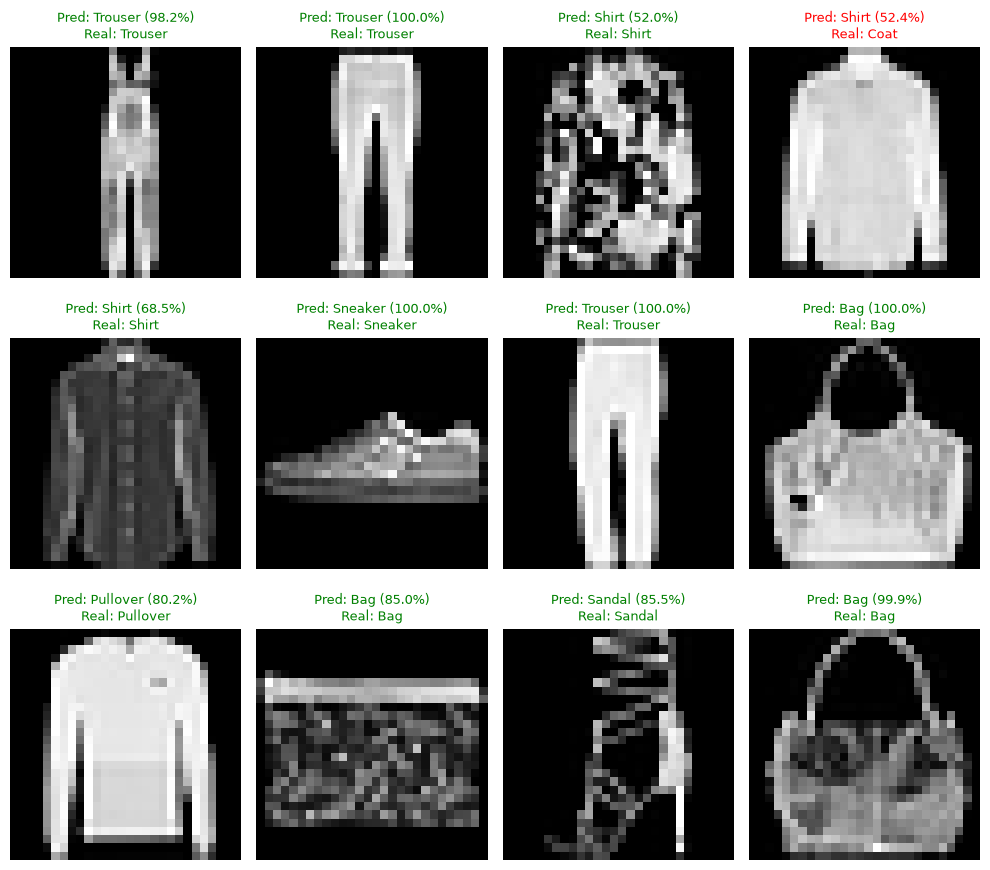

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
La predicción es correcta: Trouser (1), Real: Trouser (1)


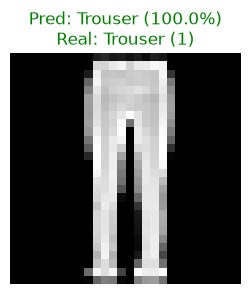

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ["KERAS_BACKEND"] = "torch"  # Ejecuta sobre PyTorch por debajo
import keras
from keras import layers
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


# 1. Cargar el dataset
datos = np.load("fashion_mnist_es1_6000.npz")
# Tomamos el dato de la etiqueta y
y = datos["y"]
# datos donde el modelo usa para aprender
X = datos["X"]
# clases definidas
clases = datos["clases"]

keras.utils.set_random_seed(42)

# 1. Preprocesamiento de los datos
# -1 indica la cantidad de datos la cual se ajusta automaticamente
# 28, 28 tamaño de la imagen
# 1 indica que es una imagen en escala de grises, como dato para una rgb se usaria 3
# por utlimo normalizamos los datos para que tenga un valor entre 0 y 1 diviendo entre 255
# esto es porque los pixeles de escalade grises contienen valores entre el 0 y 255 
X =  X.reshape(-1, 28, 28, 1) / 255.0

# 2. Separamos el entrenamiento en 80% (4800) de datos de entrenar y 20% (1200) en datos de test
# la variable y que es la etiqueta es la que queremos predecir
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Configurar el modelo
# 3.1 primero se definen 2 capas donde la primera tiene 32 nucleos los cuales se encarga de encontrar caracteristicas en un tamaño de 3x3
# a esto le definimos la forma de los datos que es (28, 28, 1)
# 3.2 luego se reduce a un vector bidimensional con el fin de reducir el costo de computo
# 3.3 segunda neurona convulcional de 64 nucleos, aca busca areas mas grandes que la primera teniendo un mayor nivel de abastracción
# tambien se reduce a bidimensional
# 3.4 la 3 capa son 64 neuronas encuentra las relaciones entre los patrones formando figuras completas usando relu para relaciones
# no lineales complejas
# 3.5 capa final que decide la clase final cada neurona con una clase
# con softmax cada clase se le da un % de cual es mas probable de ser la clase correcta
# 3.6  despues de cada capa de neuronas se incluye un dropout, que es una tecnica
# que desactiva algunas neuronas dandole valor 0 generando que las neuronas restantes tengan que aprender a generalizar mejor y no depender de otras neuronas
# esto ayuda a evitar el sobreajuste

model = keras.Sequential(
    [
        layers.Input(shape=(28, 28, 1)),
        # Bloque convolucional 1
        layers.Conv2D(32, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),  # Regularización suave en características visuales
        # Bloque convolucional 2
        layers.Conv2D(64, kernel_size=3, activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),
        # Clasificador
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),  # Regularización fuerte en la capa densa
        layers.Dense(10, activation="softmax"),
    ]
)


# compilamos el modelo antes del entrenamiento
# usando adam como funcion de gradiente, sparse_categorical_crossentropy como funcion de perdida
# y metrica de rendimiento accruracy
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

# Pasamos los datos del entrenamiento, con 20 epocas
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
)
# Predicción y reporte

predictions = model.predict(X_test)
y_pred = predictions.argmax(axis=1)
nombres_clases = [str(c) for c in clases]

# 3. Generar e imprimir el reporte
reporte = classification_report(
    y_test,
    y_pred,
    target_names=nombres_clases,
    digits=4,  
)

print(reporte)

# Configurar la cuadrícula de visualización (por ejemplo, 12 imágenes: 3 filas x 4 columnas)
num_rows = 3
num_cols = 4
num_images = num_rows * num_cols

plt.figure(figsize=(2.5 * num_cols, 3.0 * num_rows))

for i in range(num_images):
    # Obtener clase predicha, confianza y etiqueta real
    pred_label = np.argmax(predictions[i])
    confidence = 100 * np.max(predictions[i])
    true_label = y_test[i]

    # Color verde si acertó, rojo si falló
    color = "green" if pred_label == true_label else "red"

    # Graficar la imagen
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    plt.title(
        f"Pred: {clases[pred_label]} ({confidence:.1f}%)\nReal: {clases[true_label]}",
        color=color,
        fontsize=9,
        pad=6,
    )
    plt.axis("off")

plt.tight_layout(h_pad=1.5)
plt.show()



# uso de imagen especifica
x_imagen = X_test[1]
y_imagen = y_test[1]
clase_imagen = clases[y_imagen] 


predict_imagen = model.predict(x_imagen.reshape(1, 28, 28, 1))
etiqueta_predicha = np.argmax(predict_imagen)

if etiqueta_predicha == y_imagen:
    print(f"La predicción es correcta: {clases[etiqueta_predicha]} ({etiqueta_predicha}), Real: {clases[y_imagen]} ({y_imagen})")
else:
    print(f"La predicción es incorrecta. Predicha: {clases[etiqueta_predicha]} ({etiqueta_predicha}), Real: {clases[y_imagen]} ({y_imagen})")


plt.figure(figsize=(3, 3))
plt.imshow(x_imagen.squeeze(), cmap="gray")
plt.title(
    f"Pred: {clases[etiqueta_predicha]} ({100 * np.max(predictions[1]):.1f}%)\nReal: {clases[y_imagen]} ({y_imagen})",
    color="green" if etiqueta_predicha == y_imagen else "red"
)
plt.axis("off")
plt.show()
